In [1]:
# jax ecosystem
import jax

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", False)
print(jax.local_devices()[0].device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("amigo version:", amigo.__version__)

cpu
jax version: 0.7.2
zodiax version: 0.4.1
amigo version: 0.0.10


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(gethostname())

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    badpix_dir = "/Users/mc/code/amigo/src/amigo/data/badpix.npy"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/code/dorito_notebooks/files/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    badpix_dir = "/fred/oz440/max/code/amigo/src/amigo/data/badpix.npy"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# dealing with saving figures when running in script


def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


save_flag = check_script()

if save_flag:
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    if job_id == None:
        job_id = "local"
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    print(f"Save path: {save_path}")
else:
    save_path = None

maxs-mbp-14.shared.sydney.edu.au
Running in a notebook or interactive shell


In [3]:
# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[29, 69] = 1
    file["BADPIX"].data[49, 74] = 1
    file["BADPIX"].data[61, 52] = 1
    file["BADPIX"].data[53, 18] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Validation files
Calibrators from other science programs

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []


# 1093, Deepashri Thatte
program_path = os.path.join(data_dir, "1093/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] == "HD-36805"]
val_files += files

# 1843, Jens Kammerer
program_path = os.path.join(data_dir, "1843/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
val_files += files

# 1242, Doug Johnstone
program_path = os.path.join(data_dir, "1242/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] != "TD-CAL-HD-101531"]
val_files += files

val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

   program            target filter dither     g/i        date                 PI   CAL
0     1093          HD-36805  F480M    1/2    9/65  23-05-2022  Thatte, Deepashri  True
1     1093          HD-36805  F480M    2/2    9/65  23-05-2022  Thatte, Deepashri  True
2     1093          HD-36805  F430M    1/2    6/82  23-05-2022  Thatte, Deepashri  True
3     1093          HD-36805  F430M    2/2    6/82  23-05-2022  Thatte, Deepashri  True
4     1093          HD-36805  F380M    1/2   3/122  23-05-2022  Thatte, Deepashri  True
5     1093          HD-36805  F380M    2/2   3/122  23-05-2022  Thatte, Deepashri  True
6     1093          HD-36805  F480M   1/25    9/65  23-05-2022  Thatte, Deepashri  True
7     1093          HD-36805  F480M   2/25    9/65  23-05-2022  Thatte, Deepashri  True
8     1093          HD-36805  F480M   3/25    9/65  23-05-2022  Thatte, Deepashri  True
9     1093          HD-36805  F480M   4/25    9/65  23-05-2022  Thatte, Deepashri  True
10    1093          HD-36805  F4

## Calibration files
The main training data, including flats.

In [5]:
cal_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
cal_files += files

# print()
# print("CAL8330 - Benjamin Pope")
# program_path = os.path.join(data_dir, "8330/calslope/")
# files = get_files(program_path, "nis_calslope")
# cal_files += files

cal_files = [add_badpix(file) for file in cal_files]
summarise_files(cal_files)

CAL4481 - Anand Sivaramakrishnan
   program    target filter dither      g/i        date                       PI   CAL
0     4481  HD-41094  F480M    1/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1     4481  HD-41094  F480M    2/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
2     4481  HD-41094  F480M    3/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
3     4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
4     4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
5     4481  HD-41094  F380M    1/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
6     4481  HD-41094  F380M    2/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
7     4481  HD-41094  F380M    3/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
8     4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
9     4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
10    4481

Flats.

In [6]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files

flat_files = [
    add_badpix(file) for file in flat_files if file[0].header["NGROUPS"] != 45  # Louis
]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  CLEAR    1/1  25/11  10-02-2023  Martel, Andre  FLAT
2    1503  UNKNOWN  CLEAR    1/1  20/33  10-02-2023  Martel, Andre  FLAT
3    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT
4    4472  UNKNOWN  F277W    1/1  20/10  28-10-2023  Martel, Andre  FLAT
5    4472  UNKNOWN  F356W    1/1  20/10  29-04-2024  Martel, Andre  FLAT
6    6654  UNKNOWN  CLEAR    1/1  10/11  22-07-2024  Martel, Andre  FLAT
7    6654  UNKNOWN  F430M    1/1  30/10  27-07-2024  Martel, Andre  FLAT
8    6654  UNKNOWN  F444W    1/1  20/10  29-10-2024  Martel, Andre  FLAT


# Exposures

Some bad pixel stuff.

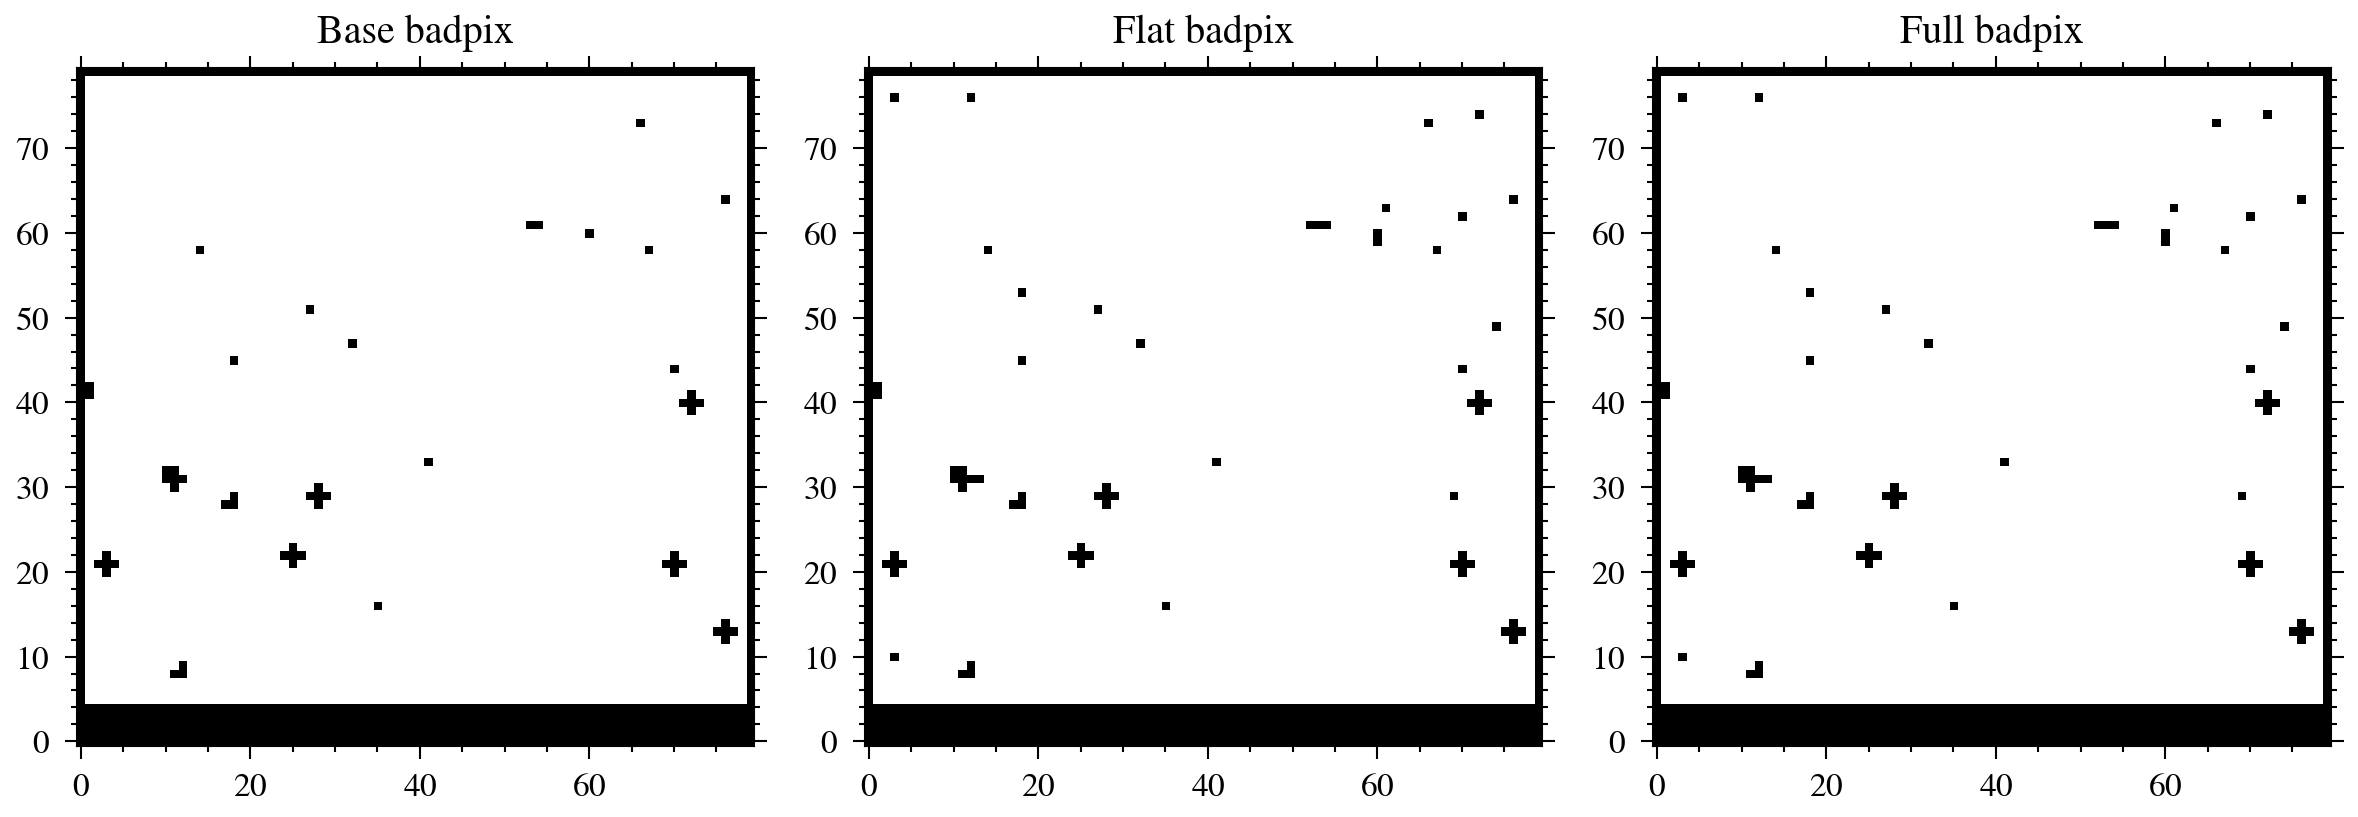

In [7]:
base_badpix = np.load(badpix_dir)

flat_badpix = np.zeros((80, 80))
for file in flat_files:
    flat_badpix = np.array(file["BADPIX"].data)
    flat_badpix += flat_badpix.astype(int)
flat_badpix = ~(flat_badpix == 0)
full_badpix = flat_badpix | base_badpix


def add_badpix_again(file):
    badpix = np.array(file["BADPIX"].data, dtype=bool)
    file["BADPIX"].data = (badpix | full_badpix).astype(int)
    return file


fig, ax = plt.subplots(1, 3, figsize=(8, 3))
ax[0].imshow(base_badpix, cmap="grey_r")
ax[0].set_title("Base badpix")
ax[1].imshow(flat_badpix, cmap="grey_r")
ax[1].set_title("Flat badpix")
ax[2].imshow(full_badpix, cmap="grey_r")
ax[2].set_title("Full badpix")
plt.tight_layout()

if save_flag:
    plt.savefig(os.path.join(save_path, "badpix.png"), dpi=200)
    plt.close()
else:
    plt.show()

In [8]:
from amigo.model_fits import PointFit, FlatFit

# Construct the exposures
# flat_exposures = [FlatFit(add_badpix_again(file)) for file in flat_files]
cal_exposures = [PointFit(add_badpix_again(file)) for file in cal_files]
# val_exposures = [PointFit(add_badpix_again(file)) for file in val_files]
# exposures = cal_exposures + flat_exposures + val_exposures
exposures = cal_exposures[0:1]

# just closing the files
files = cal_files + val_files + flat_files
_ = [f.close() for f in files]

Finally, let's batch the exposures for training.

In [9]:
# from amigo.fitting import batch_exposures

# # Get the batches: Calibrator, flats, and validators
# cal_batch = batch_exposures(cal_exposures, batch_size=3, key="cal")
# flat_batch = batch_exposures(flat_exposures, batch_size=3, key="flat")
# val_batch = batch_exposures(val_exposures, batch_size=3, key="val")
# batches = {**cal_batch, **flat_batch}

# Building model

In [10]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
)

Populate from state.

In [11]:
state = np.load(f"{amigo_files_path}/calibration.npy", allow_pickle=True).item()
print(state.keys())

for key, value in state.items():
    if key in ["positions", "fluxes", "aberrations", "nn_weights"]:
        continue
    if key in ["transmission", "badpix"]:
        continue
    model = model.set(key, value)

ab_dict = {}
for key, _ in model.aberrations.items():
    prog, filt = key.split("_")
    ab_dict[key] = state["aberrations"][filt]

model = model.set("aberrations", ab_dict)

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix'])


In [12]:
# for exp in cal_exposures:

#     for i in [0, -1]:
#         # for i in [0]:

#         badpix = exp.badpix
#         data = np.where(badpix, np.nan, exp.ramp[i])
#         ramp = np.where(badpix, np.nan, exp(model, return_slopes=False)[i])
#         res = data - ramp
#         v = np.nanmax(np.abs(res))

#         plt.figure(figsize=(15, 4))
#         plt.subplot(1, 3, 1)
#         plt.imshow(data, inferno)
#         plt.colorbar()

#         plt.subplot(1, 3, 2)
#         plt.imshow(ramp, inferno)
#         plt.colorbar()

#         plt.subplot(1, 3, 3)
#         plt.imshow(res, seismic, vmin=-v, vmax=v)
#         plt.colorbar()

#         plt.tight_layout()
#         plt.show()

#         plt.figure(figsize=(15, 4))
#         plt.subplot(1, 3, 1)
#         plt.hist(res.flatten(), bins=100)

#         plt.subplot(1, 3, 2)
#         plt.scatter(data, ramp)
#         xs = np.linspace(np.nanmin(data), np.nanmax(data), 1000)
#         plt.plot(xs, xs, c="k")

#         plt.subplot(1, 3, 3)
#         plt.scatter(data, res, alpha=0.05)

#         plt.tight_layout()
#         plt.show()
#     break

## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

F430M


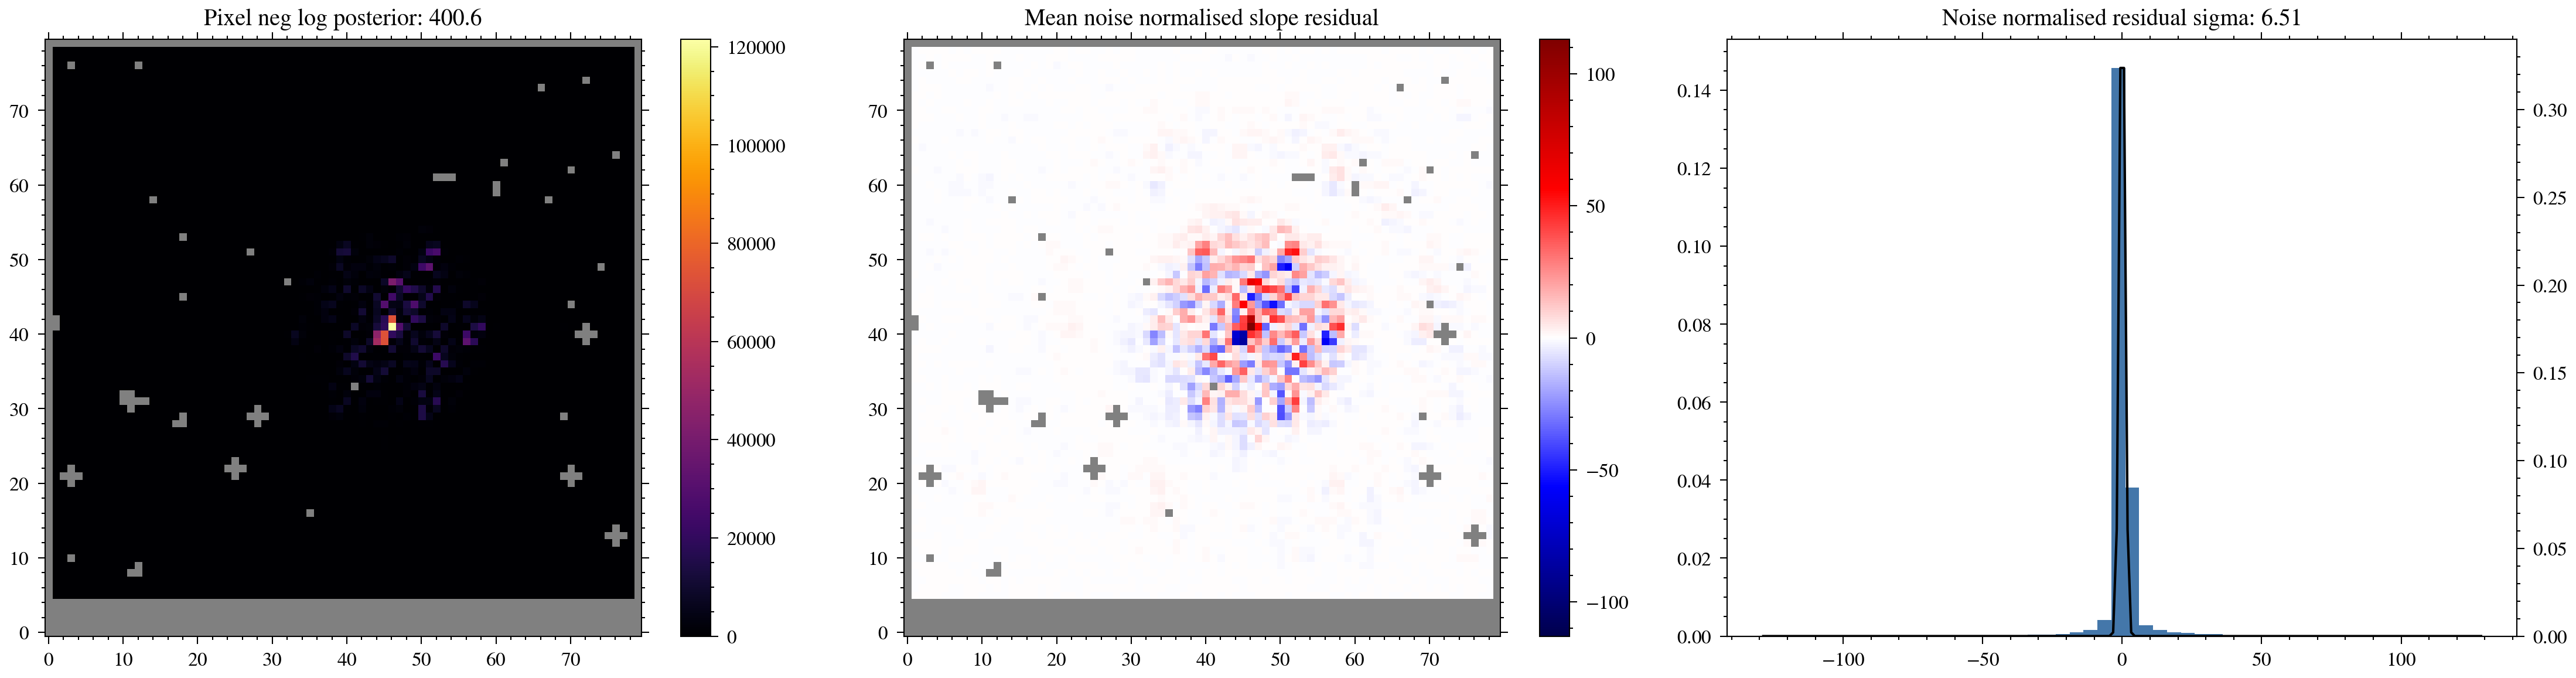

In [13]:
from amigo.plotting import summarise_fit

done = []
for exp in exposures:
    # for exp in cal_exposures:
    if exp.filter in done:
        continue
    print(exp.filter)
    summarise_fit(model, exp)
    # summarise_fit(model, exp, save_path=save_path)
    done.append(exp.filter)

Now the validator exposures.

In [14]:
# from amigo.plotting import summarise_fit

# done = []
# for exp in val_exposures:
#     if exp.filter in done:
#         continue
#     print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
#     summarise_fit(model, exp, save_path=save_path)
#     done.append(exp.filter)

Finally, the flats.

In [15]:
# from amigo.plotting import summarise_fit

# for exp in flat_exposures:
#     print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
#     summarise_fit(model, exp, save_path=save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [16]:
# def norm_fn(model_params, args):
#     """
#     Normalisation function.
#     """
#     if hasattr(model_params, "FF"):
#         FF = model_params.FF
#         FF -= np.median(FF) - 1.0
#         FF = FF.at[badpix].set(1.0)
#         model_params = model_params.set("FF", FF)

#     if hasattr(model_params, "non_linearity"):
#         non_lin = model_params.non_linearity.at[:, badpix].set(0)
#         model_params = model_params.set("non_linearity", non_lin)

#     return model_params, args


def posterior(model, exposure, ff_std=0.035, nl_std=0.025):
    """
    Custom posterior function to handle the learning
    rate warm-up and temperature decay.
    """

    # Loss
    z_score = exposure.mv_zscore(model)

    # # L2 regularisation
    # l2_reg = -l2_norm * np.mean(model.nn_weights**2)

    # FF prior
    ff_norm = model.FF - 1
    ff_reg = -np.mean((ff_norm / ff_std) ** 2)

    # Non linearity prior
    nl_norm = model.non_linearity - model.non_linearity.mean()
    nl_reg = -np.mean((nl_norm / nl_std) ** 2)

    prior = ff_reg + nl_reg  # + l2_reg

    return z_score + prior, (z_score, ff_reg, nl_reg)


def loss_fn(model, exposure, args={}):
    """
    Custom loss function to handle the learning
    rate warm-up and temperature decay.
    """
    loss, args = posterior(model, exposure, l2_norm=0.0)
    return -np.nanmean(loss), (-np.nanmean(args[0]), *args[1:])


def basic_loss_fn(model, exp, args={}):
    """Compute a regularised negative-log-likelihood for ramp data.

    Returns the scalar loss for a single exposure and a placeholder tuple
    (kept for amigo API compatibility).
    """

    # regular likelihood term
    # likelihood = -np.nanmean(exp.loglike(model))
    # likelihood = np.nanmean(exp.mv_zscore(model))
    likelihood = -np.nanmean(exp.mv_zscore(model))

    return likelihood, ()


# def args_fn(model, args, epoch):
#     """
#     Custom args function to handle the learning
#     rate warm-up and temperature decay.
#     """
#     args["l2"] = args["l2_schedule"][epoch]
#     return model, args


def cosine_warmup(t, t0, n_max):
    # Make the cosine curve
    x = (t - t0) * np.pi / n_max
    half_cos = 0.5 * (1 + (np.cos(x + np.pi)))

    # Set all values > n to 1.
    half_cos = np.where(t > n_max + t0, 1, half_cos)
    half_cos = np.where(t < t0, 0.0, half_cos)
    return half_cos


def temp_decay(T0, k, t):
    return T0 * np.exp(-k * t)


def get_warmup(args):
    return cosine_warmup(args["t"], args["t0"], args["n_max"])


def get_temperature(args):
    return temp_decay(args["T0"], args["k"], args["t"])


def grads_fn(model, grads, args):

    if "nn_weights" not in grads.params.keys():
        return grads, args

    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    rand_vals = get_temperature(args) * jr.normal(key, values.shape)
    values += rand_vals

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    # Update with the new values
    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)
    return grads, args

In [17]:
epochs = 10
# # n_batch = len(batches)

# # WARM UP
# max_lr = 1.0  # Learning rate after warm up
# t0 = 0  # Warm-up start
# n_max = 100  # Warm-up end

# # TEMPERATURE DECAY
# T0 = 1e-6  # Initial temperature
# decay = 0.005  # Decay rate of the temperature

# args = {
#     "n_batch": np.array(n_batch, float),  # Number of batches
#     "key": jr.key(0),  # RNG Key
#     "t": np.array(0.0),  # Initial time step
#     "T0": np.array(T0),  # Initial temperature
#     "k": np.array(decay),  # Decay rate
#     "t0": np.array(t0),  # Warm-up start
#     "n_max": np.array(n_max),  # Warm-up end point
#     "max_lr": np.array(max_lr),  # Learning rate after warm up
# }

# ts = np.arange(epochs)
# temps = temp_decay(args["T0"], args["k"], ts)
# lrs = cosine_warmup(ts, args["t0"], args["n_max"])

# plt.figure(figsize=(4, 2))
# plt.title("Learning rate and temperature schedules")
# plt.plot(ts, temps / temps.max(), label="Temperature")
# plt.plot(ts, lrs / lrs.max(), label="Learning rate")
# plt.xlabel("Epochs")
# plt.legend()

# plt.tight_layout()
# if save_flag:
#     plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
#     plt.close()
# else:
#     plt.show()

Instantiating trainer class and updating fishers.

In [18]:
# from amigo.calibration import ValBatchedTrainer, looper_fn, aux_fn
from amigo.calibration import Trainer

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# # Trainer class
# trainer = ValBatchedTrainer(
#     loss_fn,
#     # args_fn=args_fn,
#     looper_fn=looper_fn,
#     grad_fn=grads_fn,
#     norm_fn=norm_fn,
#     aux_fn=aux_fn,
#     cache=cache_dir,
# )

# # FLATS
# trainer = trainer.update_fishers(
#     linear_model,
#     flat_exposures,
#     parameters=["flat_coeffs", "fluxes"],
# )

# # VALIDATORS
# trainer = trainer.update_fishers(
#     linear_model,
#     val_exposures,
#     batch_size=20,
#     parameters=["positions", "aberrations", "fluxes", "spectra"],
# )

# NOTE: SPLIT UP THE CAL FISHERS FOR BATCHING

trainer = Trainer(
    # loss_fn,
    basic_loss_fn,
    # args_fn=args_fn,
    # looper_fn=looper_fn,
    # grad_fn=grads_fn,
    # norm_fn=norm_fn,
    # aux_fn=aux_fn,
    cache=cache_dir,
)

# CALIBRATORS
trainer = trainer.update_fishers(
    # model,
    linear_model,
    exposures,
    recalculate=True,
    # cal_exposures,
    parameters=[
        "positions",
        "fluxes",
        # "spectra",
        # "jitter",
        # "dark_current",
        # "SRF",
        # "distortion",
        # "defocus",
        # "aberrations",
        # "primary_beam",
    ],
)

  0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
trainer.fishers

{'04481_001_06_03_2.fluxes': Array([[-7.76945824e-08]], dtype=float64),
 '04481_001_06_03_2.positions': Array([[-1.47895886e-06, -1.70953151e-07],
        [-1.70953151e-07, -1.31938946e-06]], dtype=float64)}

Training.

In [20]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    # "nn_weights": adam(1e-3, 10),  # lr applied with warm up
    "positions": sgd(1e-1, 0),
    "fluxes": sgd(1e-1, 0),
    # "flat_coeffs": sgd(2e-2, 0),
    # "aberrations": sgd(2e-2 * 1e-14, 5),
    # "jitter": sgd(1e-2, 15),  # start at 50th?
    # "defocus": sgd(2e-1, 25),
    # "distortion": sgd(5e-2, 30),
    # "dark_current": sgd(2e-2, 35),
    # "primary_beam": sgd(1e-2, 40),
    # "non_linearity": sgd(1e-4, 100),
    # "FF": sgd(2e-4, 150),
    # "SRF": sgd(2e-3, 250),
    # "spectra": sgd(5e-2, 1000),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jtu.map(fn, model)

# Train the model
# with jax.disable_jit():
result = trainer.train(
    # model=linear_model,
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    # batches=val_exposures[0:1],
    batches=exposures,
    # batches=cal_exposures[0:1],
    # batches=cal_exposures,
    # batches=batches,
    # validators=val_batch,
    # batched_params=["nn_weights"],
    # validator_params=["positions", "fluxes", "aberrations", "spectra"],
    # args=args,
)

  0%|          | 0/10 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 402.66


EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/Users/mc/miniconda3/envs/retrain/lib/python3.12/asyncio/base_events.py", li

In [21]:
exps = exposures

amigo.plotting.plot_losses(result.losses[0], start=int(epochs * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

NameError: name 'result' is not defined